<Figure size 640x480 with 0 Axes>

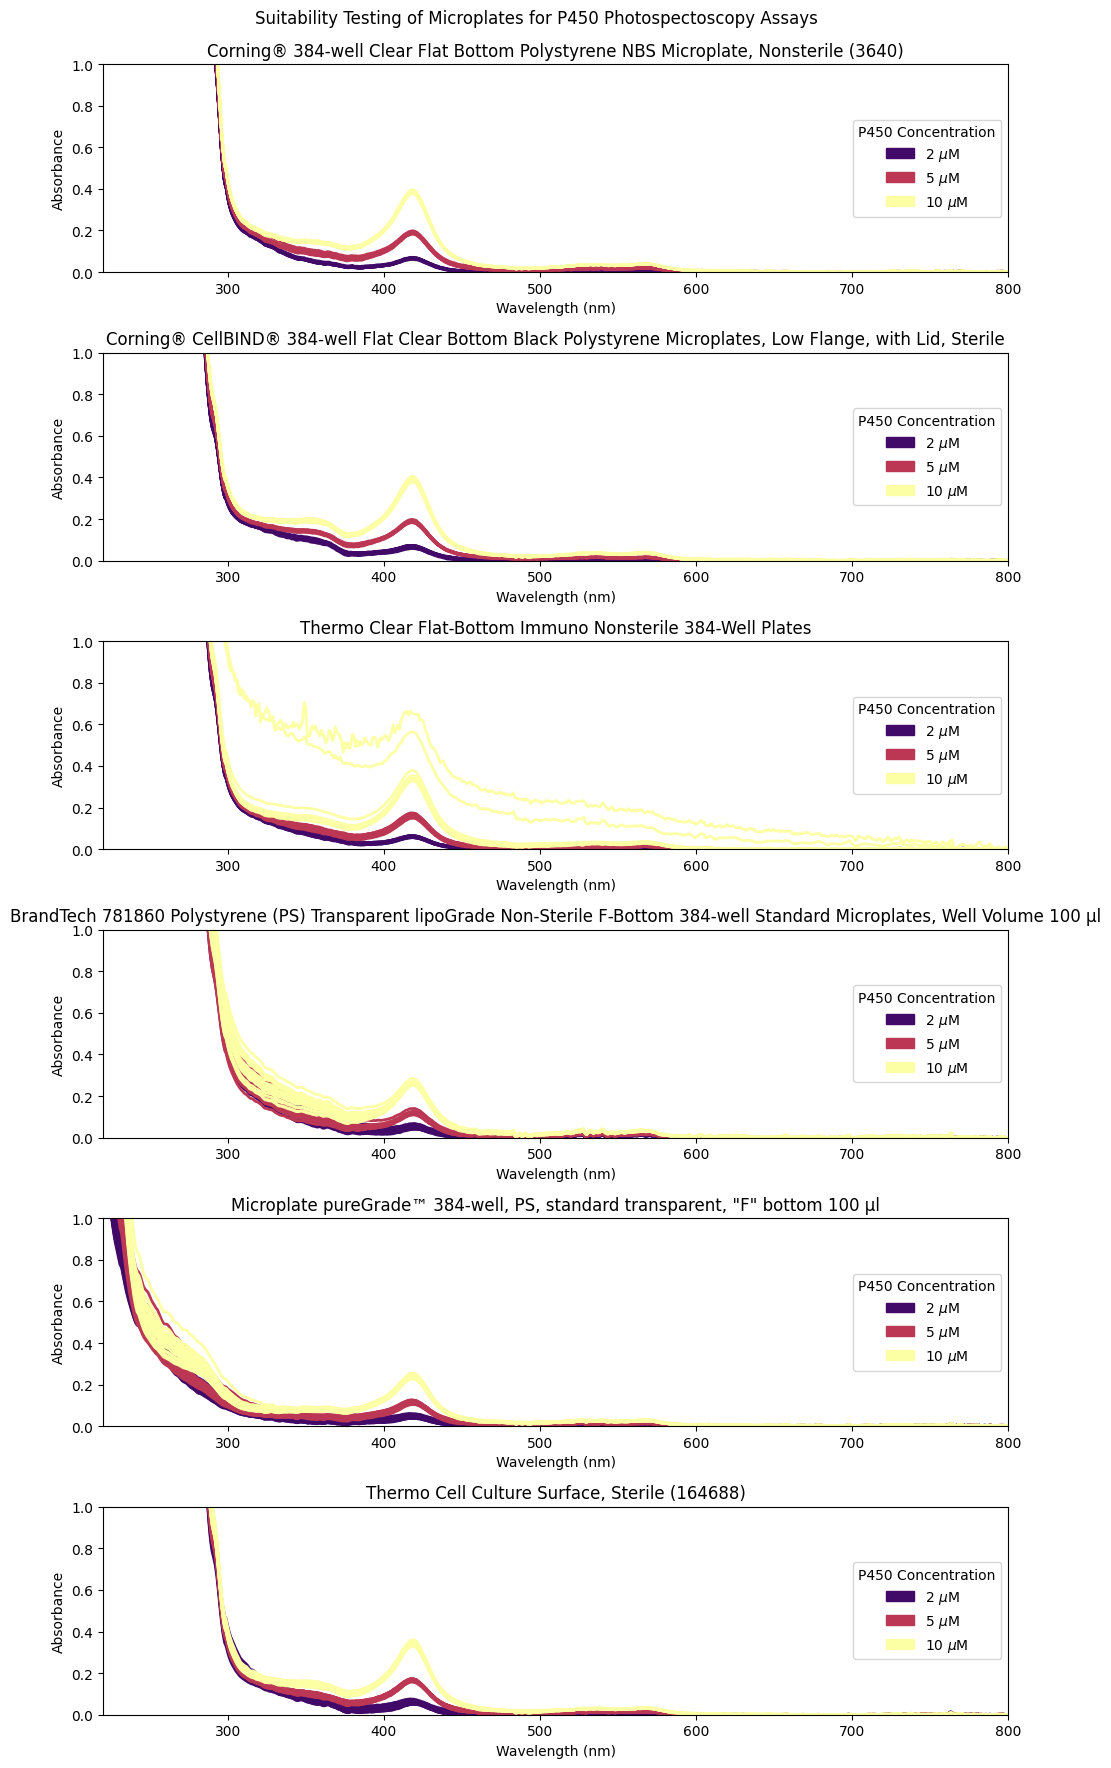

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import utils

plt.set_cmap('inferno')

save_dir = 'plate_types'
data_dir = '../1_PlateSelection'

files = {
    #'36640.CSV': 'Corning® 384-well Clear Flat Bottom Polystyrene NBS Microplate, Nonsterile (3640)',
    '36640_2.CSV': 'Corning® 384-well Clear Flat Bottom Polystyrene NBS Microplate, Nonsterile (3640)',
    #'3770bc.CSV': 'Corning® CellBIND® 384-well Flat Clear Bottom Black Polystyrene Microplates, Low Flange, with Lid, Sterile',
    '3770bc_2.CSV': 'Corning® CellBIND® 384-well Flat Clear Bottom Black Polystyrene Microplates, Low Flange, with Lid, Sterile',
    '464718.CSV': 'Thermo Clear Flat-Bottom Immuno Nonsterile 384-Well Plates',    
    #'464718_2.CSV': 'Thermo Clear Flat-Bottom Immuno Nonsterile 384-Well Plates',
    #'761860.CSV': 'BrandTech 781860 Polystyrene (PS) Transparent lipoGrade Non-Sterile F-Bottom 384-well Standard Microplates, Well Volume 100 µl',   
    '761860_2.CSV': 'BrandTech 781860 Polystyrene (PS) Transparent lipoGrade Non-Sterile F-Bottom 384-well Standard Microplates, Well Volume 100 µl',
    #'781620.CSV': 'Microplate pureGrade™ 384-well, PS, standard transparent, "F" bottom 100 µl',
    '781620_2.CSV': 'Microplate pureGrade™ 384-well, PS, standard transparent, "F" bottom 100 µl',
    #'DELTA.CSV': 'Thermo Cell Culture Surface, Sterile (164688)',
    'DELTA_2.CSV': 'Thermo Cell Culture Surface, Sterile (164688)',
}

plate_columns_concs = {
    1: 2,
    2: 5,
    3: 10,
}


if not os.path.exists(save_dir):
    os.mkdir(save_dir)

colors = plt.cm.inferno(np.array([2, 5, 10])/10)

fig, axs = plt.subplots(len(files),
                       1,
                       figsize=(10, len(files) * 3),
                      )

patch_props = [
    {'color': colors[i - 1], 'label': f'{plate_columns_concs[i]} $\mu$M' } for i in plate_columns_concs
]

for file_name, ax in zip(files, axs.flatten()):
    
    plate_name = files[file_name]
    df = utils.parse.bmg(os.path.join(data_dir, file_name))
    df = df.subtract(df[800], axis=0)
    
    for column_num in plate_columns_concs:
        concentration = plate_columns_concs[column_num]
        data = df.loc[df.index.str.contains(str(column_num)), :]
        utils.plot.plot_traces_nb(data,
                                  ax=ax,
                                  c=colors[column_num - 1],
                                  lw=2,
                                  ylim=(0, 1),
                                 )
        
    handles, labels = ax.get_legend_handles_labels()
    for patch in patch_props:
        handles.append(mpatches.Patch(**patch))
    ax.legend(handles=handles, title='P450 Concentration', loc='right')
    
    ax.set_title(plate_name)

fig.suptitle('Suitability Testing of Microplates for P450 Photospectoscopy Assays\n')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'suitability-testing.png'))
plt.show()

In [2]:
sorted(set(files.values()))

['BrandTech 781860 Polystyrene (PS) Transparent lipoGrade Non-Sterile F-Bottom 384-well Standard Microplates, Well Volume 100 µl',
 'Corning® 384-well Clear Flat Bottom Polystyrene NBS Microplate, Nonsterile (3640)',
 'Corning® CellBIND® 384-well Flat Clear Bottom Black Polystyrene Microplates, Low Flange, with Lid, Sterile',
 'Microplate pureGrade™ 384-well, PS, standard transparent, "F" bottom 100 µl',
 'Thermo Cell Culture Surface, Sterile (164688)',
 'Thermo Clear Flat-Bottom Immuno Nonsterile 384-Well Plates']

In [5]:
160/50

3.2

In [6]:
254.00 /30

8.466666666666667

In [7]:
646.19 / 100

6.461900000000001

In [8]:
128.62/50

2.5724

In [13]:
price_data = pd.DataFrame(
    [
        {'Name': 'BrandTech 781860 Polystyrene (PS) Transparent lipoGrade Non-Sterile F-Bottom 384-well Standard Microplates, Well Volume 100 µl',
         'Product Number': '781860',
         'Material': 'Polystyrene',
         'Treatment': '',
         'Estimated Price Per Unit (GBP)': 2.57,
        },
         {'Name': 'Corning® 384-well Clear Flat Bottom Polystyrene NBS Microplate, Nonsterile (3640)',
         'Product Number': '3640',
         'Material': 'Polystyrene',
         'Treatment': 'Non-ionic hydrophilic',
         'Estimated Price Per Unit (GBP)': 6.46,
         },
         {'Name': 'Corning® CellBIND® 384-well Flat Clear Bottom Black Polystyrene Microplates, Low Flange, with Lid, Sterile',
         'Product Number': '3770bc_2',
         'Material': 'Polystyrene',
         'Treatment': 'Cellbind',
         'Estimated Price Per Unit (GBP)': 13.39,
         },
         {'Name': 'Microplate pureGrade™ 384-well, PS, standard transparent, "F" bottom 100 µl',
         'Product Number': '781620',
         'Material': 'Polystyrene',
         'Treatment': '',
         'Estimated Price Per Unit (GBP)': 3.20,
         },
         {'Name': 'Thermo Cell Culture Surface, Sterile (164688)',
         'Product Number': '164688',
         'Material': 'Polystyrene',
         'Treatment': 'Nunclon Delta',
         'Estimated Price Per Unit (GBP)': 26.40,
         },
         {'Name': 'Thermo Clear Flat-Bottom Immuno Nonsterile 384-Well Plates',
         'Product Number': '464718',
         'Material': 'Polystyrene',
         'Treatment': 'MaxiSorp',
         'Estimated Price Per Unit (GBP)': 8.47,
         },
    ]
)
print(price_data.to_markdown(index=False))

| Name                                                                                                                           | Product Number   | Material    | Treatment             |   Estimated Price Per Unit (GBP) |
|:-------------------------------------------------------------------------------------------------------------------------------|:-----------------|:------------|:----------------------|---------------------------------:|
| BrandTech 781860 Polystyrene (PS) Transparent lipoGrade Non-Sterile F-Bottom 384-well Standard Microplates, Well Volume 100 µl | 781860           | Polystyrene |                       |                             2.57 |
| Corning® 384-well Clear Flat Bottom Polystyrene NBS Microplate, Nonsterile (3640)                                              | 3640             | Polystyrene | Non-ionic hydrophilic |                             6.46 |
| Corning® CellBIND® 384-well Flat Clear Bottom Black Polystyrene Microplates, Low Flange, with Lid, Sterile